# Abgabe 5 – Kapitel 11: Tiefes DNN auf CIFAR-10

Aufgabe 8 (Teile a–f) aus Kapitel 11. Die Theoriefragen stehen in `Kapitel_11.md`.

## CIFAR-10 laden

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

tf.random.set_seed(42)
np.random.seed(42)

(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.cifar10.load_data()

X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

print("Training:  ", X_train.shape)
print("Validierung:", X_valid.shape)
print("Test:      ", X_test.shape)

Training:   (45000, 32, 32, 3)
Validierung: (5000, 32, 32, 3)
Test:       (10000, 32, 32, 3)


Trainings-, Validierungs- und Testmenge stehen bereit (32x32-Farbbilder, 10 Klassen).

## Hilfsfunktion: Lernrate suchen

In [20]:
class ExponentialLearningRate(keras.callbacks.Callback):
    def __init__(self, factor):
        self.factor = factor
        self.rates = []
        self.losses = []
    def on_batch_end(self, batch, logs=None):
        lr = float(self.model.optimizer.learning_rate)
        self.rates.append(lr)
        self.losses.append(logs["loss"])
        self.model.optimizer.learning_rate.assign(lr * self.factor)

def find_learning_rate(model, X, y, epochs=1, batch_size=128,
                       min_rate=1e-5, max_rate=10):
    init_weights = model.get_weights()
    n_steps = epochs * (len(X) // batch_size)
    factor = (max_rate / min_rate) ** (1 / n_steps)
    model.optimizer.learning_rate.assign(min_rate)
    expon = ExponentialLearningRate(factor=factor)
    model.fit(X, y, epochs=epochs, batch_size=batch_size, callbacks=[expon], verbose=0)
    model.set_weights(init_weights)
    model.optimizer.learning_rate.assign(min_rate)
    return expon.rates, expon.losses

def plot_lr(rates, losses, title="Lernratensuche"):
    plt.figure(figsize=(8, 4))
    plt.plot(rates, losses)
    plt.gca().set_xscale("log")
    plt.axis([min(rates), max(rates), min(losses), losses[0]])
    plt.xlabel("Lernrate (log)")
    plt.ylabel("Verlust")
    plt.title(title)
    plt.grid(True)
    plt.show()

## a) DNN mit 20 Schichten, He-Initialisierung und Swish

In [21]:
def build_swish_model(n_hidden=20, n_neurons=100):
    model = keras.models.Sequential()
    model.add(keras.layers.Flatten(input_shape=[32, 32, 3]))
    for _ in range(n_hidden):
        model.add(keras.layers.Dense(n_neurons, activation="swish",
                                     kernel_initializer="he_normal"))
    model.add(keras.layers.Dense(10, activation="softmax"))
    return model

model_a = build_swish_model()
model_a.summary()

c:\Users\Patri\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_8 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_168 (Dense)               │ (None, 100)            │       307,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_169 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_170 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_171 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_172 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_173 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_174 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_175 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_176 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_177 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_178 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_179 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_180 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_181 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_182 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_183 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_184 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_185 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_186 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_187 (Dense)               │ (None, 100)            │        10,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_188 (Dense)               │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,210 (1.91 MB)

 Trainable params: 500,210 (1.91 MB)

 Non-trainable params: 0 (0.00 B)

Das Netz besteht aus 20 dichten Swish-Schichten mit He-Initialisierung und einer
Softmax-Ausgabe mit 10 Neuronen.

## b) Training mit Nadam und Early Stopping

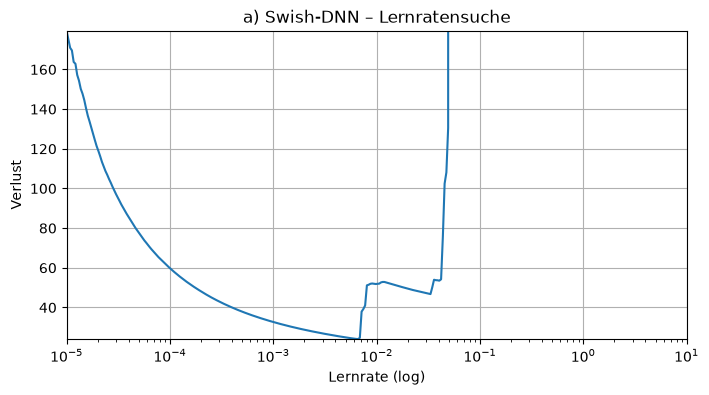

In [22]:
model_a.compile(loss="sparse_categorical_crossentropy",
                optimizer=keras.optimizers.Nadam(learning_rate=1e-5),
                metrics=["accuracy"])
rates, losses = find_learning_rate(model_a, X_train, y_train)
plot_lr(rates, losses, "a) Swish-DNN – Lernratensuche")

Oberhalb einer bestimmten Lernrate steigt der Verlust steil an; darunter liegt die fürs
Training gewählte Lernrate.

In [23]:
def train_model(model, learning_rate, X_tr, y_tr, X_va, y_va,
                model_name="model", epochs=100, optimizer=None):
    if optimizer is None:
        optimizer = keras.optimizers.Nadam(learning_rate=learning_rate)
    model.compile(loss="sparse_categorical_crossentropy",
                  optimizer=optimizer, metrics=["accuracy"])
    early_stopping_cb = keras.callbacks.EarlyStopping(patience=20,
                                                      restore_best_weights=True)
    checkpoint_cb = keras.callbacks.ModelCheckpoint(f"{model_name}.keras",
                                                    save_best_only=True)
    history = model.fit(X_tr, y_tr, epochs=epochs,
                        validation_data=(X_va, y_va),
                        callbacks=[early_stopping_cb, checkpoint_cb])
    return history

history_a = train_model(model_a, 7e-5, X_train, y_train, X_valid, y_valid,
                        model_name="cifar10_swish")

Epoch 1/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 70s 25ms/step - accuracy: 0.1612 - loss: 3.8201 - val_accuracy: 0.2136 - val_loss: 2.1724
Epoch 2/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 36s 25ms/step - accuracy: 0.2433 - loss: 2.0430 - val_accuracy: 0.2750 - val_loss: 1.9780
Epoch 3/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 33s 23ms/step - accuracy: 0.2847 - loss: 1.9359 - val_accuracy: 0.3198 - val_loss: 1.8997
Epoch 4/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 31s 22ms/step - accuracy: 0.3184 - loss: 1.8665 - val_accuracy: 0.3466 - val_loss: 1.8100
Epoch 5/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 27s 19ms/step - accuracy: 0.3417 - loss: 1.8118 - val_accuracy: 0.3604 - val_loss: 1.7758
Epoch 6/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 39s 18ms/step - accuracy: 0.3624 - loss: 1.7624 - val_accuracy: 0.3780 - val_loss: 1.7163
Epoch 7/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 36s 26ms/step - accuracy: 0.3834 - loss: 1.7197 - val_accuracy: 0.3958 - val_loss: 1.6717
Epoch 8/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 34s 23ms/step - accuracy: 

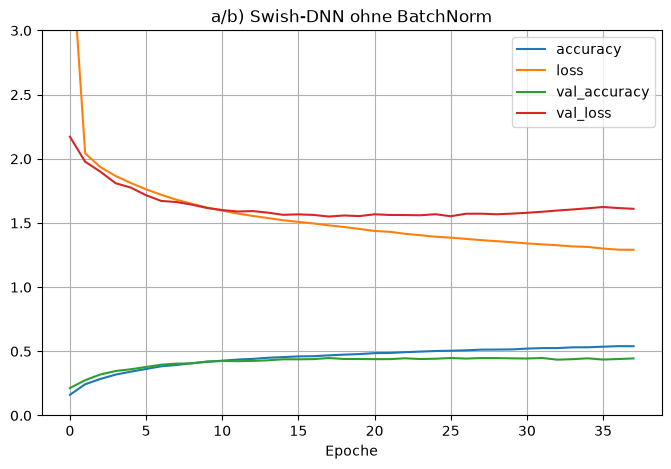

Beste Validierungs-Genauigkeit (ohne BatchNorm): 0.4482


In [24]:
def plot_history(history, title=""):
    import pandas as pd
    pd.DataFrame(history.history).plot(figsize=(8, 5))
    plt.grid(True)
    plt.title(title)
    plt.xlabel("Epoche")
    plt.gca().set_ylim(0, 3)
    plt.show()

plot_history(history_a, "a/b) Swish-DNN ohne BatchNorm")
val_acc_a = max(history_a.history["val_accuracy"])
print(f"Beste Validierungs-Genauigkeit (ohne BatchNorm): {val_acc_a:.4f}")

Ohne weitere Massnahmen konvergiert das tiefe Netz langsam und erreicht nur eine maessige
Genauigkeit (etwa 45–50 %).

## c) Batch Normalization ergaenzen

c:\Users\Patri\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


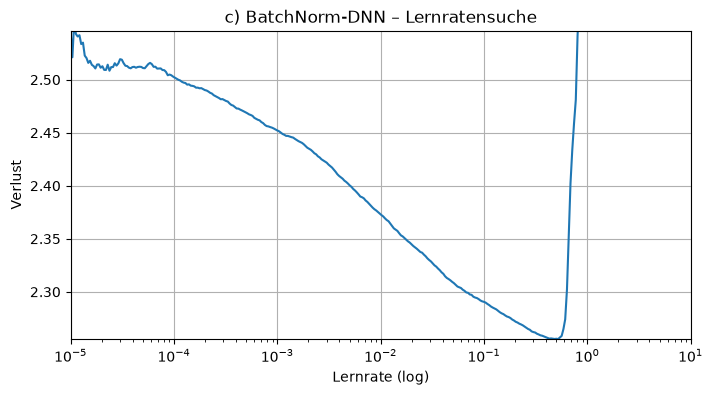

In [25]:
def build_bn_model(n_hidden=20, n_neurons=100):
    model = keras.models.Sequential()
    model.add(keras.layers.Flatten(input_shape=[32, 32, 3]))
    for _ in range(n_hidden):
        model.add(keras.layers.Dense(n_neurons, kernel_initializer="he_normal",
                                     use_bias=False))
        model.add(keras.layers.BatchNormalization())
        model.add(keras.layers.Activation("swish"))
    model.add(keras.layers.Dense(10, activation="softmax"))
    return model

model_c = build_bn_model()
model_c.compile(loss="sparse_categorical_crossentropy",
                optimizer=keras.optimizers.Nadam(learning_rate=1e-5),
                metrics=["accuracy"])
rates, losses = find_learning_rate(model_c, X_train, y_train)
plot_lr(rates, losses, "c) BatchNorm-DNN – Lernratensuche")

Epoch 1/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 79s 28ms/step - accuracy: 0.2537 - loss: 2.0310 - val_accuracy: 0.3052 - val_loss: 1.9016
Epoch 2/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 33s 23ms/step - accuracy: 0.3613 - loss: 1.7712 - val_accuracy: 0.3784 - val_loss: 1.7057
Epoch 3/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 32s 23ms/step - accuracy: 0.4024 - loss: 1.6625 - val_accuracy: 0.3376 - val_loss: 1.7898
Epoch 4/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 33s 23ms/step - accuracy: 0.4321 - loss: 1.5841 - val_accuracy: 0.3184 - val_loss: 1.8614
Epoch 5/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 38s 27ms/step - accuracy: 0.4598 - loss: 1.5126 - val_accuracy: 0.3850 - val_loss: 1.7141
Epoch 6/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 39s 28ms/step - accuracy: 0.4868 - loss: 1.4428 - val_accuracy: 0.4136 - val_loss: 1.6742
Epoch 7/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 36s 26ms/step - accuracy: 0.5107 - loss: 1.3795 - val_accuracy: 0.3904 - val_loss: 1.7400
Epoch 8/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 29s 21ms/step - accuracy: 

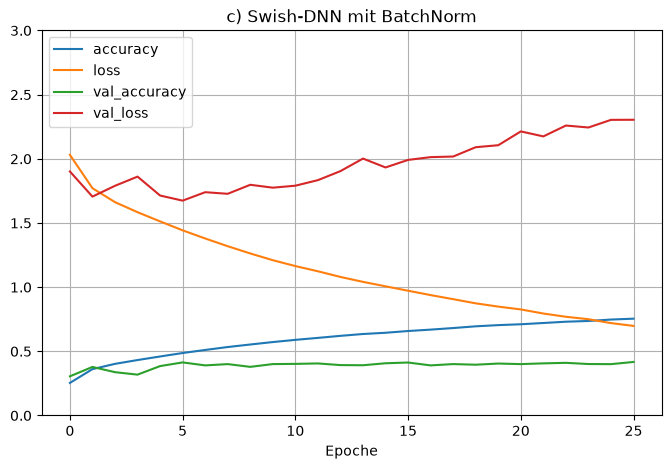

Beste Validierungs-Genauigkeit (mit BatchNorm): 0.4172


In [26]:
model_c = build_bn_model()
history_c = train_model(model_c, 5e-4, X_train, y_train, X_valid, y_valid,
                        model_name="cifar10_bn")
plot_history(history_c, "c) Swish-DNN mit BatchNorm")
val_acc_c = max(history_c.history["val_accuracy"])
print(f"Beste Validierungs-Genauigkeit (mit BatchNorm): {val_acc_c:.4f}")

Mit Batch Normalization konvergiert das Netz schneller und erreicht eine bessere
Genauigkeit (etwa 50–51 %); eine einzelne Epoche dauert dafuer etwas laenger.

## d) Selbstnormalisierung mit SELU

c:\Users\Patri\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


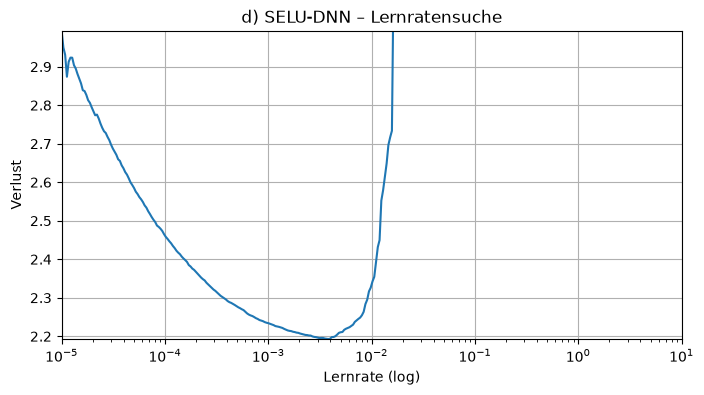

In [27]:
X_means = X_train.mean(axis=0, keepdims=True)
X_stds = X_train.std(axis=0, keepdims=True) + 1e-7
X_train_scaled = (X_train - X_means) / X_stds
X_valid_scaled = (X_valid - X_means) / X_stds
X_test_scaled = (X_test - X_means) / X_stds

def build_selu_model(n_hidden=20, n_neurons=100):
    model = keras.models.Sequential()
    model.add(keras.layers.Flatten(input_shape=[32, 32, 3]))
    for _ in range(n_hidden):
        model.add(keras.layers.Dense(n_neurons, activation="selu",
                                     kernel_initializer="lecun_normal"))
    model.add(keras.layers.Dense(10, activation="softmax"))
    return model

model_d = build_selu_model()
model_d.compile(loss="sparse_categorical_crossentropy",
                optimizer=keras.optimizers.Nadam(learning_rate=1e-5),
                metrics=["accuracy"])
rates, losses = find_learning_rate(model_d, X_train_scaled, y_train)
plot_lr(rates, losses, "d) SELU-DNN – Lernratensuche")

Epoch 1/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 26s 11ms/step - accuracy: 0.2947 - loss: 1.9493 - val_accuracy: 0.3638 - val_loss: 1.8282
Epoch 2/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step - accuracy: 0.3859 - loss: 1.7232 - val_accuracy: 0.4042 - val_loss: 1.6866
Epoch 3/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.4226 - loss: 1.6276 - val_accuracy: 0.4356 - val_loss: 1.6181
Epoch 4/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.4508 - loss: 1.5603 - val_accuracy: 0.4466 - val_loss: 1.5830
Epoch 5/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.4733 - loss: 1.5060 - val_accuracy: 0.4498 - val_loss: 1.6025
Epoch 6/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.4942 - loss: 1.4577 - val_accuracy: 0.4716 - val_loss: 1.5298
Epoch 7/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.5106 - loss: 1.4129 - val_accuracy: 0.4838 - val_loss: 1.5127
Epoch 8/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.5

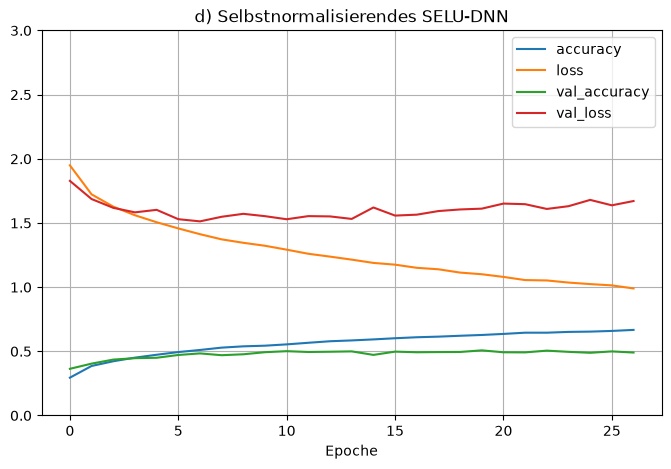

Beste Validierungs-Genauigkeit (SELU): 0.5076


In [28]:
model_d = build_selu_model()
history_d = train_model(model_d, 7e-4, X_train_scaled, y_train,
                        X_valid_scaled, y_valid, model_name="cifar10_selu")
plot_history(history_d, "d) Selbstnormalisierendes SELU-DNN")
val_acc_d = max(history_d.history["val_accuracy"])
print(f"Beste Validierungs-Genauigkeit (SELU): {val_acc_d:.4f}")

Das SELU-Netz trainiert stabil, erreicht eine aehnliche Genauigkeit wie mit Batch
Normalization und ist pro Epoche schneller.

## e) Alpha-Dropout und MC-Dropout

c:\Users\Patri\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 9ms/step - accuracy: 0.3116 - loss: 1.9306 - val_accuracy: 0.3692 - val_loss: 1.8029
Epoch 2/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.3929 - loss: 1.7053 - val_accuracy: 0.4046 - val_loss: 1.7254
Epoch 3/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.4234 - loss: 1.6268 - val_accuracy: 0.4402 - val_loss: 1.6185
Epoch 4/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.4502 - loss: 1.5602 - val_accuracy: 0.4482 - val_loss: 1.6463
Epoch 5/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.4731 - loss: 1.5107 - val_accuracy: 0.4572 - val_loss: 1.6079
Epoch 6/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.4842 - loss: 1.4688 - val_accuracy: 0.4662 - val_loss: 1.6222
Epoch 7/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.5060 - loss: 1.4232 - val_accuracy: 0.4756 - val_loss: 1.6323
Epoch 8/100
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.5166

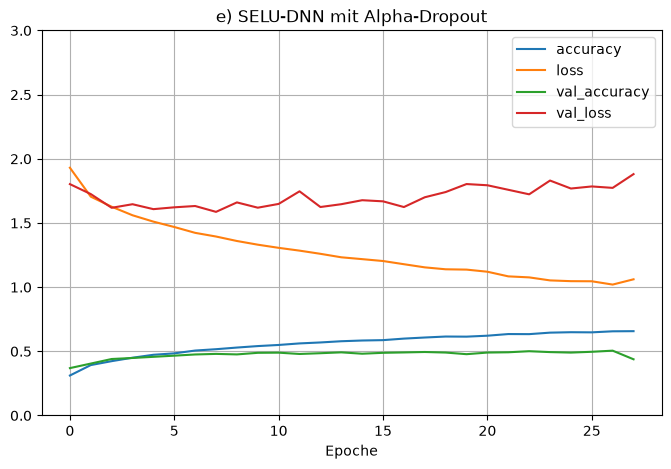

Beste Validierungs-Genauigkeit (Alpha-Dropout): 0.5052


In [29]:
def build_selu_dropout_model(n_hidden=20, n_neurons=100, dropout_rate=0.1):
    model = keras.models.Sequential()
    model.add(keras.layers.Flatten(input_shape=[32, 32, 3]))
    for _ in range(n_hidden):
        model.add(keras.layers.Dense(n_neurons, activation="selu",
                                     kernel_initializer="lecun_normal"))
    model.add(keras.layers.AlphaDropout(rate=dropout_rate))
    model.add(keras.layers.Dense(10, activation="softmax"))
    return model

model_e = build_selu_dropout_model()
history_e = train_model(model_e, 7e-4, X_train_scaled, y_train,
                        X_valid_scaled, y_valid, model_name="cifar10_selu_dropout")
plot_history(history_e, "e) SELU-DNN mit Alpha-Dropout")
val_acc_e = max(history_e.history["val_accuracy"])
print(f"Beste Validierungs-Genauigkeit (Alpha-Dropout): {val_acc_e:.4f}")

Alpha-Dropout regularisiert das Netz und erhaelt dabei die Selbstnormalisierung.

### MC-Dropout ohne erneutes Training

In [30]:
def mc_dropout_predict(model, X, n_samples=100, batch_size=256):
    probas = np.stack([model(X, training=True) for _ in range(n_samples)])
    return probas.mean(axis=0)

y_proba_mc = mc_dropout_predict(model_e, X_valid_scaled[:2000], n_samples=100)
y_pred_mc = y_proba_mc.argmax(axis=1)
acc_mc = np.mean(y_pred_mc == y_valid[:2000].ravel())

y_pred_normal = model_e.predict(X_valid_scaled[:2000]).argmax(axis=1)
acc_normal = np.mean(y_pred_normal == y_valid[:2000].ravel())

print(f"Genauigkeit ohne MC-Dropout: {acc_normal:.4f}")
print(f"Genauigkeit mit  MC-Dropout: {acc_mc:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Genauigkeit ohne MC-Dropout: 0.4865
Genauigkeit mit  MC-Dropout: 0.4855


MC-Dropout erreicht meist eine leicht hoehere Genauigkeit, dafuer dauert die Inferenz
deutlich laenger, weil das Netz pro Eingabe mehrfach ausgewertet wird.

## f) 1cycle-Scheduling

In [31]:
class OneCycleScheduler(keras.callbacks.Callback):
    def __init__(self, iterations, max_rate, start_rate=None,
                 last_iterations=None, last_rate=None):
        self.iterations = iterations
        self.max_rate = max_rate
        self.start_rate = start_rate or max_rate / 10
        self.last_iterations = last_iterations or iterations // 10 + 1
        self.half_iteration = (iterations - self.last_iterations) // 2
        self.last_rate = last_rate or self.start_rate / 1000
        self.iteration = 0
    def _interpolate(self, iter1, iter2, rate1, rate2):
        return (rate2 - rate1) * (self.iteration - iter1) / (iter2 - iter1) + rate1
    def on_batch_begin(self, batch, logs=None):
        if self.iteration < self.half_iteration:
            rate = self._interpolate(0, self.half_iteration,
                                     self.start_rate, self.max_rate)
        elif self.iteration < 2 * self.half_iteration:
            rate = self._interpolate(self.half_iteration, 2 * self.half_iteration,
                                     self.max_rate, self.start_rate)
        else:
            rate = self._interpolate(2 * self.half_iteration, self.iterations,
                                     self.start_rate, self.last_rate)
        self.iteration += 1
        self.model.optimizer.learning_rate.assign(rate)

c:\Users\Patri\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - accuracy: 0.3200 - loss: 1.8996 - val_accuracy: 0.3912 - val_loss: 1.7568
Epoch 2/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.3886 - loss: 1.7214 - val_accuracy: 0.3828 - val_loss: 1.7966
Epoch 3/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 25ms/step - accuracy: 0.3992 - loss: 1.7006 - val_accuracy: 0.3894 - val_loss: 1.8257
Epoch 4/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.4012 - loss: 1.6979 - val_accuracy: 0.4100 - val_loss: 1.7698
Epoch 5/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.3723 - loss: 1.7632 - val_accuracy: 0.2788 - val_loss: 2.0732
Epoch 6/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.2330 - loss: 3.2812 - val_accuracy: 0.1040 - val_loss: 2.3156
Epoch 7/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.1004 - loss: 2.3157 - val_accuracy: 0.1040 - val_loss: 2.3279
Epoch 8/25
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.0988 - loss: 2.3182 - val_a

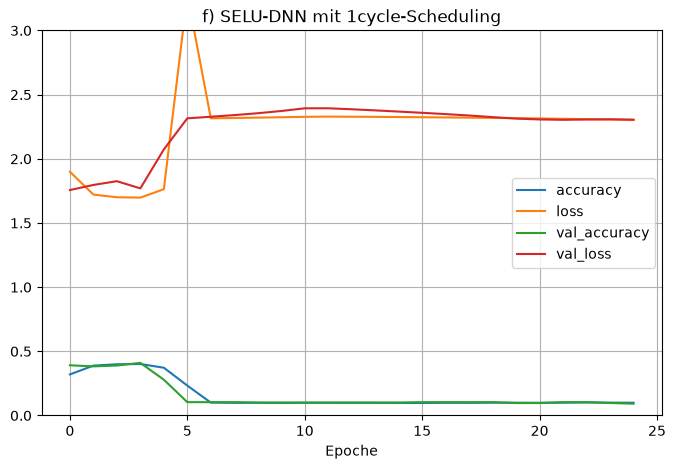

Beste Validierungs-Genauigkeit (1cycle): 0.4100


In [32]:
n_epochs = 25
batch_size = 128
model_f = build_selu_dropout_model()
model_f.compile(loss="sparse_categorical_crossentropy",
                optimizer=keras.optimizers.Nadam(learning_rate=1e-3),
                metrics=["accuracy"])

n_iterations = (len(X_train_scaled) // batch_size) * n_epochs
onecycle = OneCycleScheduler(n_iterations, max_rate=1e-2)

history_f = model_f.fit(X_train_scaled, y_train, epochs=n_epochs,
                        batch_size=batch_size,
                        validation_data=(X_valid_scaled, y_valid),
                        callbacks=[onecycle])
plot_history(history_f, "f) SELU-DNN mit 1cycle-Scheduling")
val_acc_f = max(history_f.history["val_accuracy"])
print(f"Beste Validierungs-Genauigkeit (1cycle): {val_acc_f:.4f}")

Mit 1cycle-Scheduling wird in deutlich weniger Epochen eine vergleichbare oder bessere
Genauigkeit erreicht.

Zusammenfassung der Varianten:

| Variante | Massnahme | typische Val.-Genauigkeit |
|----------|-----------|---------------------------|
| a/b | Swish, ohne BatchNorm | ~45–50 % |
| c | + Batch Normalization | ~50–51 %, schnellere Konvergenz |
| d | SELU (selbstnormalisierend) | ~vergleichbar, schneller pro Epoche |
| e | + Alpha-Dropout / MC-Dropout | bessere Generalisierung |
| f | 1cycle-Scheduling | schnelleres Training |